<a href="https://colab.research.google.com/github/RoshanMaharjan7/6S012-Artificial-Intelligence-and-Machine-Learning/blob/main/2408424_Roshan_Maharjan_Worksheet_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Roshan Maharjan\
Student Id: 2408424

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Worksheet Week 4

## Exercise: Building a Fully Connected Network (FCN) for Devnagari Digit Classification

In [18]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


In [19]:
import os
import zipfile
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image

### Task 1: Data Preparation

Loading the Data

• Download the provided folder that contains the Devnagari digits dataset.

• Use the Python Imaging Library (PIL) to load and read the image files from the dataset.

• Convert the images into Numpy arrays and normalize them to a range of 0-1.

• use train folder for training and test for testing.

• Extract the corresponding labels for each image.

Hints:

• Ensure that the images are resized to a consistent shape (e.g., 28x28).

• Convert labels to one-hot encoded format for multi-class classification

In [20]:
from google.colab import drive
drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/Sem 6/AI/Week 4/devnagari digit.zip"
extract_path = "/content/drive/MyDrive/Sem 6/AI/Week 4/devnagari_digit"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

for root, dirs, files in os.walk(extract_path):
    print(root)

base_path = extract_path

if len(os.listdir(base_path)) == 1:
    base_path = os.path.join(base_path, os.listdir(base_path)[0])

train_dir = os.path.join(base_path, "Train")
test_dir = os.path.join(base_path, "Test")

print("Train Path:", train_dir)
print("Test Path:", test_dir)

img_size = 28

def load_data(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for file in os.listdir(class_path):
            img_path = os.path.join(class_path, file)

            img = Image.open(img_path).convert("L")
            img = img.resize((img_size, img_size))
            img = np.array(img) / 255.0

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

x_train, y_train = load_data(train_dir)
x_test, y_test = load_data(test_dir)

x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Train Set shape:", x_train.shape, y_train.shape)
print("Test Set shape:", x_test.shape, y_test.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset extracted!
/content/drive/MyDrive/Sem 6/AI/Week 4/devnagari_digit
/content/drive/MyDrive/Sem 6/AI/Week 4/devnagari_digit/DevanagariHandwrittenDigitDataset
/content/drive/MyDrive/Sem 6/AI/Week 4/devnagari_digit/DevanagariHandwrittenDigitDataset/Test
/content/drive/MyDrive/Sem 6/AI/Week 4/devnagari_digit/DevanagariHandwrittenDigitDataset/Test/digit_0
/content/drive/MyDrive/Sem 6/AI/Week 4/devnagari_digit/DevanagariHandwrittenDigitDataset/Test/digit_1
/content/drive/MyDrive/Sem 6/AI/Week 4/devnagari_digit/DevanagariHandwrittenDigitDataset/Test/digit_2
/content/drive/MyDrive/Sem 6/AI/Week 4/devnagari_digit/DevanagariHandwrittenDigitDataset/Test/digit_3
/content/drive/MyDrive/Sem 6/AI/Week 4/devnagari_digit/DevanagariHandwrittenDigitDataset/Test/digit_4
/content/drive/MyDrive/Sem 6/AI/Week 4/devnagari_digit/DevanagariHandwrittenDigitDataset/Test/digit_5
/c

### Task 2: Build the FCN Model

Model Architecture

• Create a Sequential model using Keras.

• Add 3 hidden layers with the following number of neurons:

– 1st hidden layer: 64 neurons

– 2nd hidden layer: 128 neurons

– 3rd hidden layer: 256 neurons

• Use sigmoid activation functions for all hidden layers.

• Add an output layer with 10 units with softmax (since Devnagari digits have 10 classes) and a
softmax activation function.

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='sigmoid', input_shape=(784,)),
    Dense(128, activation='sigmoid'),
    Dense(256, activation='sigmoid'),
    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

### Task 3: Compile the Model

Model Compilation

• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy), and evaluation metric (e.g., accuracy)

In [22]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Task 4: Train the Model

Model Training

• Use the model.fit() function to train the model. Set the batch size to 128 and the number of
epochs to 20.

• Use validation split (validation data. (split=0.2) to monitor the model’s performance on validation data.

• Optionally, use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model
and avoiding overfitting.

In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3),
    ModelCheckpoint("best_model.h5", save_best_only=True)
]

history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/20
105/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2645 - loss: 2.0004

107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4304 - loss: 1.6610 - val_accuracy: 0.0000e+00 - val_loss: 7.2774
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8157 - loss: 0.5935 - val_accuracy: 0.0000e+00 - val_loss: 8.4076
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9075 - loss: 0.3057 - val_accuracy: 0.0000e+00 - val_loss: 9.2402
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9428 - loss: 0.1976 - val_accuracy: 0.0000e+00 - val_loss: 9.6510


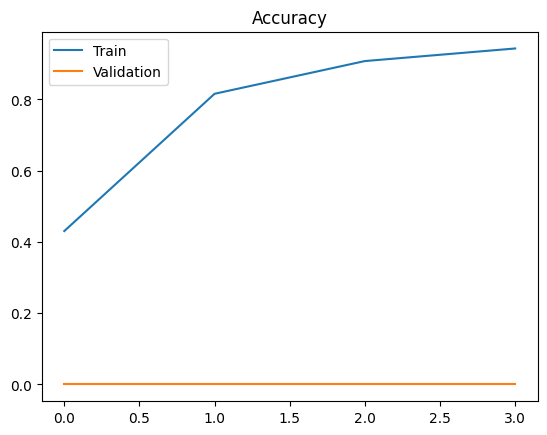

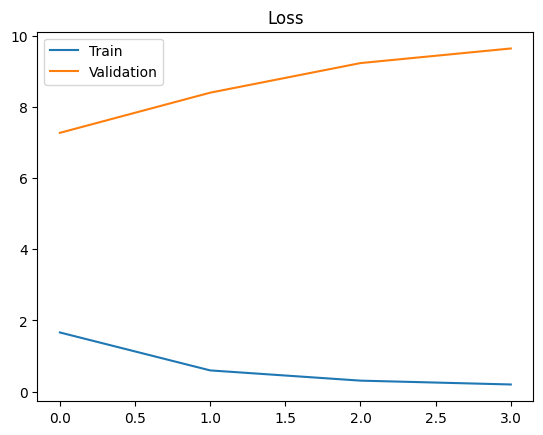

In [24]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Validation"])
plt.show()

### Task 5: Evaluate the Model

Model Evaluation

• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.



In [25]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {(test_acc * 100):.2f}%")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7573 - loss: 2.0830
Test Accuracy: 75.73%


### Task 6: Save and Load the Model

Model Saving and Loading

• Save the trained model to an .h5 file using model.save().

• Load the saved model and re-evaluate its performance on the test set.


In [26]:
model.save("devnagari_model.h5")

loaded_model = tf.keras.models.load_model("devnagari_model.h5")

loss, acc = loaded_model.evaluate(x_test, y_test)
print(f"Loaded Model Accuracy:  {(acc * 100):.2f}%", )

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7573 - loss: 2.0830
Loaded Model Accuracy:  75.73%


### Task 7: Predictions

Making Predictions

• Use model.predict() to make predictions on test images.

• Convert the model’s predicted probabilities to digit labels using np.argmax().

In [27]:
predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

print("Predicted:", predicted_labels[0])
print("Actual:", true_labels[0])

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted: 0
Actual: 0
